# **Tarea 3: Análisis, Desarrollo y Refinamiento**
## **Proyecto Integrado de Ciencia de Datos: Impacto de la IA Generativa en Estudiantes**

Este Jupyter Notebook unifica y consolida todas las etapas del ciclo de vida del proyecto, estructurando una narrativa (*storytelling*) que detalla desde la comprensión del problema y el Análisis Exploratorio de Datos (EDA), hasta el modelamiento predictivo, diagnóstico mediante validación cruzada y optimización de hiperparámetros.

In [1]:
# ============================================================
# CONFIGURACIÓN GENERAL E IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de estilos visuales para gráficos premium
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('Librerías importadas correctamente e inicialización de entorno completada.')

Librerías importadas correctamente e inicialización de entorno completada.


## **Módulo 1: Comprensión del Problema, EDA y Selección de Variables**
En esta sección abordamos la carga inicial de los datos, la auditoría de tipos de datos y valores nulos, el análisis exploratorio de datos (EDA) para identificar relaciones y la justificación estadística de la selección de variables.

### 1. Ingesta y Calidad de los Datos

Cargamos el dataset [`datos/ai_student_impact_dataset.csv`](file:///home/seba/Documentos/code/Tarea3_DS/datos/ai_student_impact_dataset.csv) descargado.

In [2]:
# Carga del dataset
df = pd.read_csv('datos/ai_student_impact_dataset.csv')

print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print('\nPrimeros registros:')
df.head()

Dimensiones del dataset: 50000 filas × 16 columnas

Primeros registros:


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


#### Auditoría de Tipos de Datos y Valores Faltantes

In [3]:
print('Tipos de datos de las columnas:')
print(df.dtypes)

print('\nConteo de valores nulos por columna:')
print(df.isnull().sum())

Tipos de datos de las columnas:
Student_ID                      int64
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object

Conteo de valores nulos por columna:
Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Ho

### 2. Análisis Exploratorio de Datos (EDA)

#### 2.1 Estadísticas Descriptivas

In [4]:
print('Variables Numéricas:')
display(df.describe().round(2))

print('\nConteo de Categorías para Variables de Interés:')
for col in ['Major_Category', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy']:
    print(f'\nDistribución de {col}:')
    print(df[col].value_counts())

Variables Numéricas:


,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,125000.50,3.15,8.43,2.80,11.21,3.51,4.27,3.35,75.80
std,14433.90,0.48,8.27,1.19,5.16,1.82,2.14,0.50,13.28
min,100001.00,1.18,0.00,1.00,1.00,1.00,1.00,1.00,10.78
25%,112500.75,2.83,2.39,2.00,7.56,2.00,3.00,3.02,66.82
50%,125000.50,3.21,5.80,3.00,11.18,3.00,4.00,3.42,76.00
75%,137500.25,3.52,11.72,4.00,14.71,5.00,6.00,3.75,85.19
max,150000.00,4.00,40.00,5.00,35.86,10.00,10.00,4.00,100.00



Conteo de Categorías para Variables de Interés:

Distribución de Major_Category:
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

Distribución de Primary_Use_Case:
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

Distribución de Prompt_Engineering_Skill:
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

Distribución de Institutional_Policy:
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64


#### 2.2 Visualización de Relaciones Numéricas (`sns.regplot`)

Analizaremos gráficamente la relación de variables predictoras clave contra nuestra variable objetivo: `Post_Semester_GPA`.

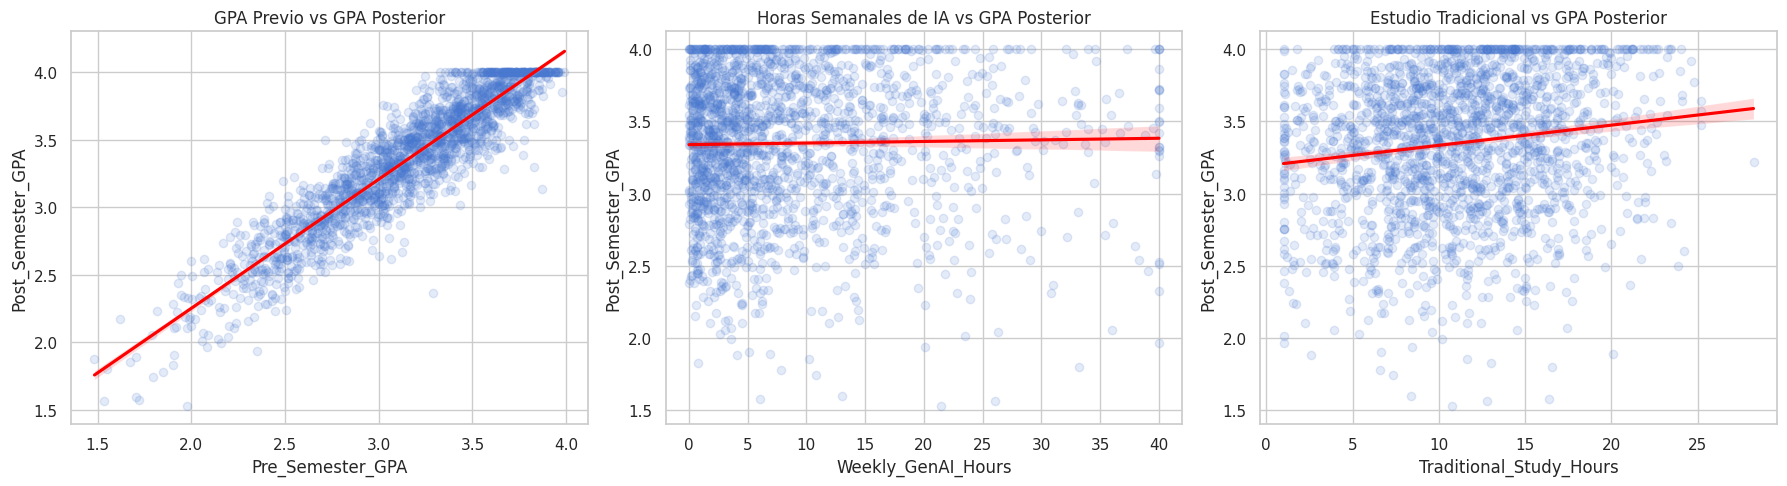

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GPA Previo vs GPA Posterior
sns.regplot(data=df.sample(2000, random_state=42), x='Pre_Semester_GPA', y='Post_Semester_GPA', 
            ax=axes[0], scatter_kws={'alpha': 0.15}, line_kws={'color': 'red'})
axes[0].set_title('GPA Previo vs GPA Posterior')

# Horas de IA vs GPA Posterior
sns.regplot(data=df.sample(2000, random_state=42), x='Weekly_GenAI_Hours', y='Post_Semester_GPA', 
            ax=axes[1], scatter_kws={'alpha': 0.15}, line_kws={'color': 'red'})
axes[1].set_title('Horas Semanales de IA vs GPA Posterior')

# Horas de Estudio Tradicional vs GPA Posterior
sns.regplot(data=df.sample(2000, random_state=42), x='Traditional_Study_Hours', y='Post_Semester_GPA', 
            ax=axes[2], scatter_kws={'alpha': 0.15}, line_kws={'color': 'red'})
axes[2].set_title('Estudio Tradicional vs GPA Posterior')

plt.tight_layout()
plt.show()

#### 2.3 Visualización de Relaciones Categóricas (`sns.boxplot`)

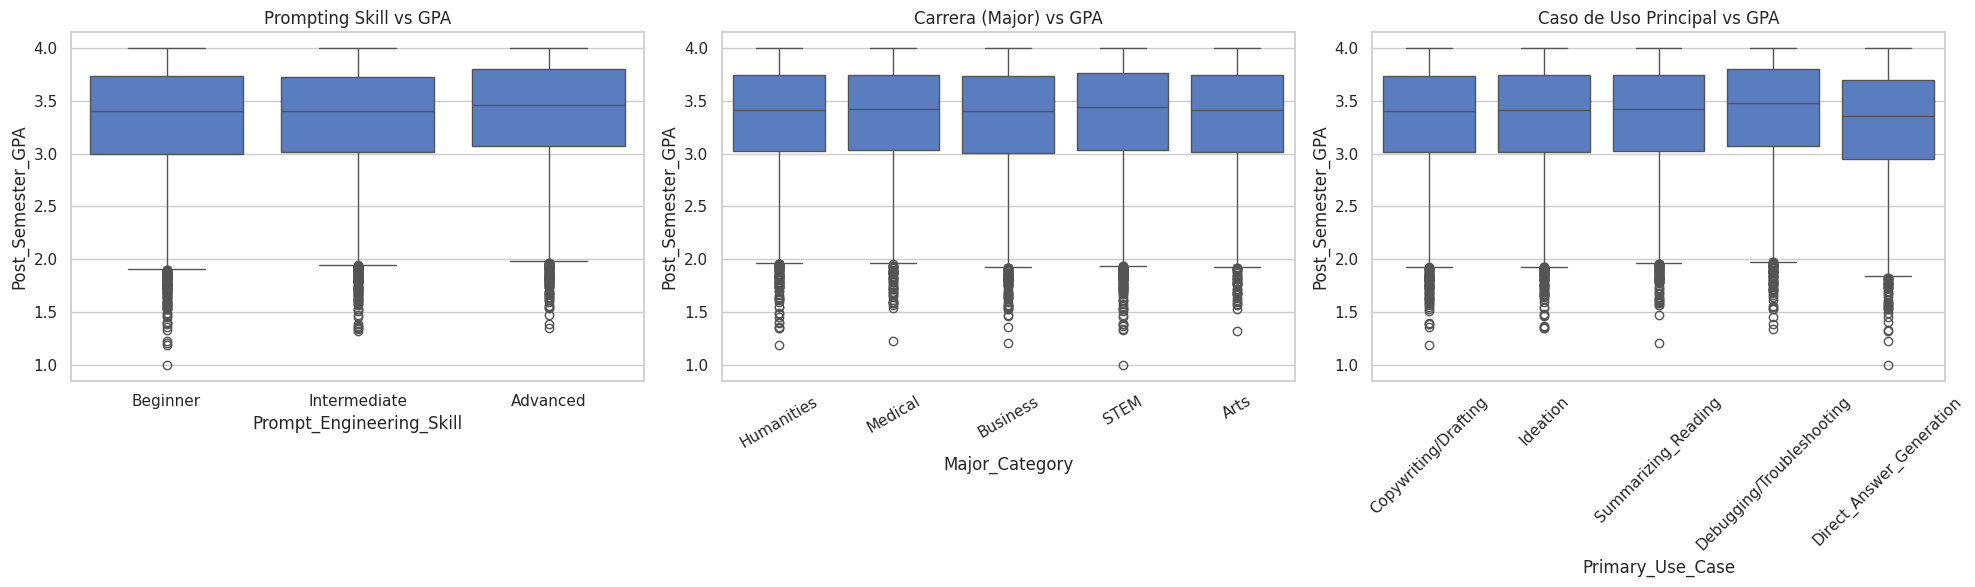

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Habilidad de Prompting vs GPA Posterior
sns.boxplot(data=df, x='Prompt_Engineering_Skill', y='Post_Semester_GPA', ax=axes[0], order=['Beginner', 'Intermediate', 'Advanced'])
axes[0].set_title('Prompting Skill vs GPA')

# Categoría de Carrera (Major) vs GPA Posterior
sns.boxplot(data=df, x='Major_Category', y='Post_Semester_GPA', ax=axes[1])
axes[1].set_title('Carrera (Major) vs GPA')
axes[1].tick_params(axis='x', rotation=30)

# Caso de Uso Principal vs GPA Posterior
sns.boxplot(data=df, x='Primary_Use_Case', y='Post_Semester_GPA', ax=axes[2])
axes[2].set_title('Caso de Uso Principal vs GPA')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### 2.4 Agrupamientos y Tablas de Contingencia (`df.groupby` y `df.pivot_table`)

--- Promedio de GPA por Habilidad de Prompting y Carrera ---


Prompt_Engineering_Skill,Advanced,Beginner,Intermediate
Major_Category,,,
Arts,3.379955,3.323165,3.340424
Business,3.365201,3.324734,3.328608
Humanities,3.373182,3.340953,3.332269
Medical,3.392588,3.345269,3.332335
STEM,3.412472,3.338945,3.337389



--- Tabla Pivote: Promedio de Horas Semanales de IA según Carrera y Caso de Uso ---


Primary_Use_Case,Copywriting/Drafting,Debugging/Troubleshooting,Direct_Answer_Generation,Ideation,Summarizing_Reading
Major_Category,,,,,
Arts,7.079039,7.600061,7.286136,7.669858,7.133167
Business,8.086853,8.455982,8.397550,8.325226,7.977930
Humanities,6.876253,6.375336,6.599464,6.742134,6.879968
Medical,7.184280,7.591809,7.315104,7.673786,7.657968
STEM,10.352187,10.445044,10.689452,10.479799,10.615806


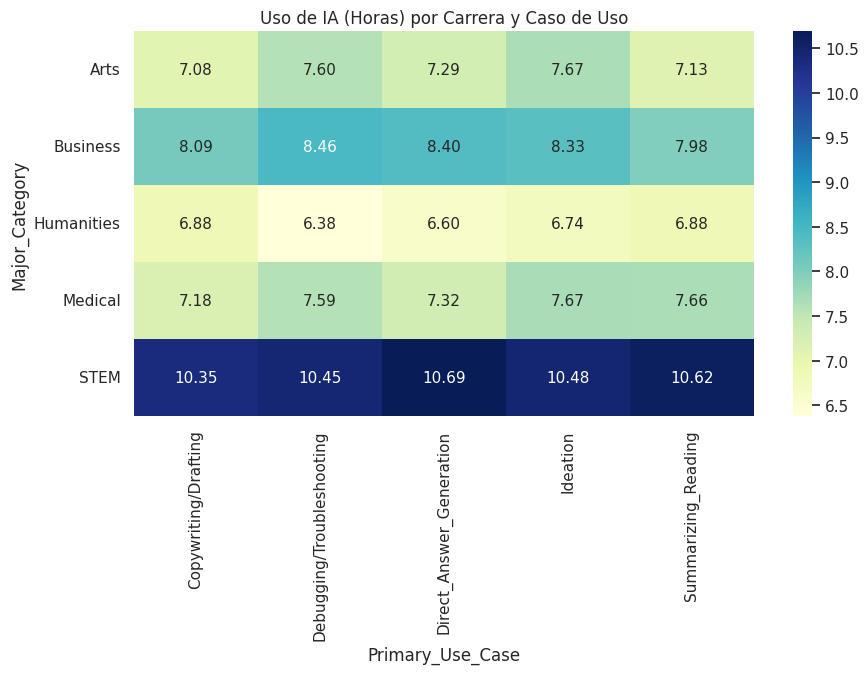

In [7]:
print('--- Promedio de GPA por Habilidad de Prompting y Carrera ---')
display(df.groupby(['Major_Category', 'Prompt_Engineering_Skill'])['Post_Semester_GPA'].mean().unstack())

print('\n--- Tabla Pivote: Promedio de Horas Semanales de IA según Carrera y Caso de Uso ---')
pivot = df.pivot_table(index='Major_Category', columns='Primary_Use_Case', values='Weekly_GenAI_Hours', aggfunc='mean')
display(pivot)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Uso de IA (Horas) por Carrera y Caso de Uso')
plt.show()

### 3. Selección de Variables

#### 3.1 Análisis de Correlación de Pearson y Heatmap

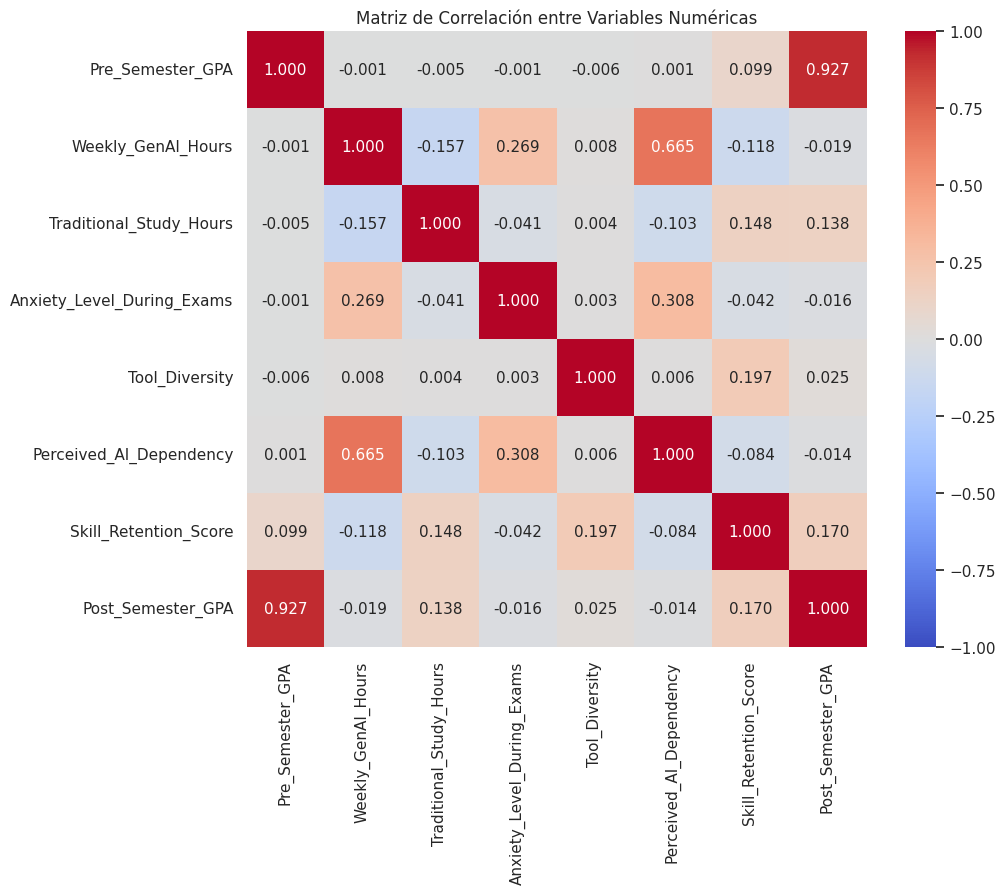

Correlación de Pearson respecto a Post_Semester_GPA:
Post_Semester_GPA             1.000000
Pre_Semester_GPA              0.926781
Skill_Retention_Score         0.169616
Traditional_Study_Hours       0.137653
Tool_Diversity                0.025265
Perceived_AI_Dependency      -0.014180
Anxiety_Level_During_Exams   -0.015909
Weekly_GenAI_Hours           -0.018600
Name: Post_Semester_GPA, dtype: float64


In [8]:
columnas_num = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 
                'Anxiety_Level_During_Exams', 'Tool_Diversity', 'Perceived_AI_Dependency', 
                'Skill_Retention_Score', 'Post_Semester_GPA']

corr_matrix = df[columnas_num].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1)
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

print('Correlación de Pearson respecto a Post_Semester_GPA:')
print(corr_matrix['Post_Semester_GPA'].sort_values(ascending=False))

#### 3.2 Validación de Variables Categóricas usando ANOVA

Validaremos si las variables categóricas muestran una diferencia estadísticamente significativa en el GPA posterior. Primero comprobamos el supuesto de homogeneidad de varianzas mediante el test de Levene.

In [9]:
print('=== TEST DE LEVENE PARA HOMOGENEIDAD DE VARIANZAS (Major_Category) ===')
grupos_major = [df[df['Major_Category'] == m]['Post_Semester_GPA'] for m in df['Major_Category'].unique()]
lev_stat, lev_p = stats.levene(*grupos_major)
print(f'Estadístico: {lev_stat:.4f} | p-valor: {lev_p:.4e}')
if lev_p > 0.05:
    print('✔ Varianzas homogéneas (Supuesto cumplido)')
else:
    print('⚠ Varianzas NO homogéneas. ANOVA debe interpretarse con cautela.')

print('\n=== ANOVA GLOBAL (Major_Category vs Post_Semester_GPA) ===')
f_stat, p_val = stats.f_oneway(*grupos_major)
print(f'F-statistic: {f_stat:.4f} | p-valor: {p_val:.4e}')
if p_val < 0.05:
    print('✔ Existen diferencias significativas en el promedio de GPA según la carrera.')
else:
    print('✘ No hay diferencias significativas.')

=== TEST DE LEVENE PARA HOMOGENEIDAD DE VARIANZAS (Major_Category) ===
Estadístico: 0.8639 | p-valor: 4.8464e-01
✔ Varianzas homogéneas (Supuesto cumplido)

=== ANOVA GLOBAL (Major_Category vs Post_Semester_GPA) ===
F-statistic: 5.5825 | p-valor: 1.7264e-04
✔ Existen diferencias significativas en el promedio de GPA según la carrera.


### 4. Conclusión y Exportación

Hemos seleccionado un conjunto de variables representativas, asegurando que cuenten con soporte gráfico y estadístico. Exportamos el dataset procesado para su modelamiento.

In [10]:
variables_modelo = [
    'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours',
    'Anxiety_Level_During_Exams', 'Tool_Diversity', 'Perceived_AI_Dependency',
    'Major_Category', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Paid_Subscription',
    'Post_Semester_GPA'
]

df_modelo = df[variables_modelo].copy()
df_modelo.to_csv('datos/ai_student_impact_procesado.csv', index=False)
print('Dataset exportado exitosamente a datos/ai_student_impact_procesado.csv')

Dataset exportado exitosamente a datos/ai_student_impact_procesado.csv


## **Módulo 2: Construcción y Evaluación de Modelos**
En esta etapa, procedemos a realizar la división del dataset en subconjuntos de entrenamiento ($Train$) y prueba ($Test$), validar estadísticamente la representatividad de la muestra, y entrenar modelos baseline y regresión lineal y polinomial.

### 5. Ingesta y División Train/Test

Cargamos el dataset procesado y creamos subconjuntos reproducibles de entrenamiento y prueba.

In [11]:
df = pd.read_csv('datos/ai_student_impact_procesado.csv')

# Separamos variables predictoras de la objetivo
X = df.drop(columns=['Post_Semester_GPA'])
y = df['Post_Semester_GPA']

# Split reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f'Entrenamiento: {X_train.shape[0]} registros | Prueba: {X_test.shape[0]} registros')

Entrenamiento: 40000 registros | Prueba: 10000 registros


### 6. Trilogía de Validación Estadística del Split


In [12]:
print('=' * 80)
print('BATERÍA DE PRUEBAS ESTADÍSTICAS PARA VALIDAR EL SPLIT')
print('=' * 80)

# 1. Test t de Welch (Comparación de medias)
t_stat, p_val_t = stats.ttest_ind(y_train, y_test, equal_var=False)
# 2. Test U de Mann-Whitney (Comparación de rangos)
u_stat, p_val_u = stats.mannwhitneyu(y_train, y_test, alternative='two-sided')
# 3. Test de Levene (Comparación de varianzas)
lev_stat, p_val_l = stats.levene(y_train, y_test, center='median')

print(f'1. Test t de Welch       | p-valor: {p_val_t:.4f} (t={t_stat:.2f})')
print(f'2. Test U Mann-Whitney   | p-valor: {p_val_u:.4f} (U={u_stat:.2f})')
print(f'3. Test de Levene        | p-valor: {p_val_l:.4f} (lev={lev_stat:.2f})')
print('-' * 80)

aprobadas = sum([p_val_t > 0.05, p_val_u > 0.05, p_val_l > 0.05])
if aprobadas == 3:
    print('VEREDICTO: SPLIT EXITOSO Y REPRESENTATIVO (3/3).')
else:
    print(f'VEREDICTO: PRECAUCIÓN. El split pasó {aprobadas}/3 criterios. Hay ligeras asimetrías.')
print('=' * 80)

BATERÍA DE PRUEBAS ESTADÍSTICAS PARA VALIDAR EL SPLIT
1. Test t de Welch       | p-valor: 0.2654 (t=-1.11)
2. Test U Mann-Whitney   | p-valor: 0.4062 (U=198928133.50)
3. Test de Levene        | p-valor: 0.4613 (lev=0.54)
--------------------------------------------------------------------------------
VEREDICTO: SPLIT EXITOSO Y REPRESENTATIVO (3/3).


### 7. Modelo Baseline (Regresión Lineal Simple)


In [13]:
X_train_base = X_train[['Pre_Semester_GPA']]
X_test_base = X_test[['Pre_Semester_GPA']]

lm_base = LinearRegression()
lm_base.fit(X_train_base, y_train)

y_pred_train_b = lm_base.predict(X_train_base)
y_pred_test_b = lm_base.predict(X_test_base)

print('=== MODELO BASELINE (PRE_SEMESTER_GPA) ===')
print(f'Train R² : {r2_score(y_train, y_pred_train_b):.4f} | Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_b)):.4f}')
print(f'Test  R² : {r2_score(y_test, y_pred_test_b):.4f} | Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_b)):.4f}')
print(f'Coeficiente (Pendiente): {lm_base.coef_[0]:.4f} | Intercepto: {lm_base.intercept_:.4f}')

=== MODELO BASELINE (PRE_SEMESTER_GPA) ===
Train R² : 0.8588 | Train RMSE: 0.1866
Test  R² : 0.8593 | Test  RMSE: 0.1843
Coeficiente (Pendiente): 0.9599 | Intercepto: 0.3287


### 8. Regresión Lineal Múltiple


In [14]:
variables_numericas = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 
                        'Anxiety_Level_During_Exams', 'Tool_Diversity', 'Perceived_AI_Dependency']
variables_categoricas = ['Major_Category', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Paid_Subscription']

# Preprocesamiento
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), variables_numericas),
    ('cat', OneHotEncoder(drop='first'), variables_categoricas)
])

# Pipeline lineal
pipeline_multi = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

pipeline_multi.fit(X_train, y_train)

y_pred_train_m = pipeline_multi.predict(X_train)
y_pred_test_m = pipeline_multi.predict(X_test)

print('=== REGRESIÓN LINEAL MÚLTIPLE ===')
print(f'Train R² : {r2_score(y_train, y_pred_train_m):.4f} | Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_m)):.4f}')
print(f'Test  R² : {r2_score(y_test, y_pred_test_m):.4f} | Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_m)):.4f}')

=== REGRESIÓN LINEAL MÚLTIPLE ===
Train R² : 0.8869 | Train RMSE: 0.1670
Test  R² : 0.8874 | Test  RMSE: 0.1649


### 9. Regresión Polinomial (Con Pipeline estructurado)


In [15]:
# Preprocesamiento con expansión polinomial solo a numéricas
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

preprocessor_poly = ColumnTransformer(transformers=[
    ('num', num_transformer, variables_numericas),
    ('cat', OneHotEncoder(drop='first'), variables_categoricas)
])

pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('regressor', LinearRegression())
])

pipeline_poly.fit(X_train, y_train)

y_pred_train_p = pipeline_poly.predict(X_train)
y_pred_test_p = pipeline_poly.predict(X_test)

print('=== REGRESIÓN POLINOMIAL GRADO 2 ===')
print(f'Train R² : {r2_score(y_train, y_pred_train_p):.4f} | Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_p)):.4f}')
print(f'Test  R² : {r2_score(y_test, y_pred_test_p):.4f} | Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_p)):.4f}')

=== REGRESIÓN POLINOMIAL GRADO 2 ===
Train R² : 0.8904 | Train RMSE: 0.1645
Test  R² : 0.8906 | Test  RMSE: 0.1625


### 10. Comparación Visual de Resultados e Residuos (Modelos Iniciales)


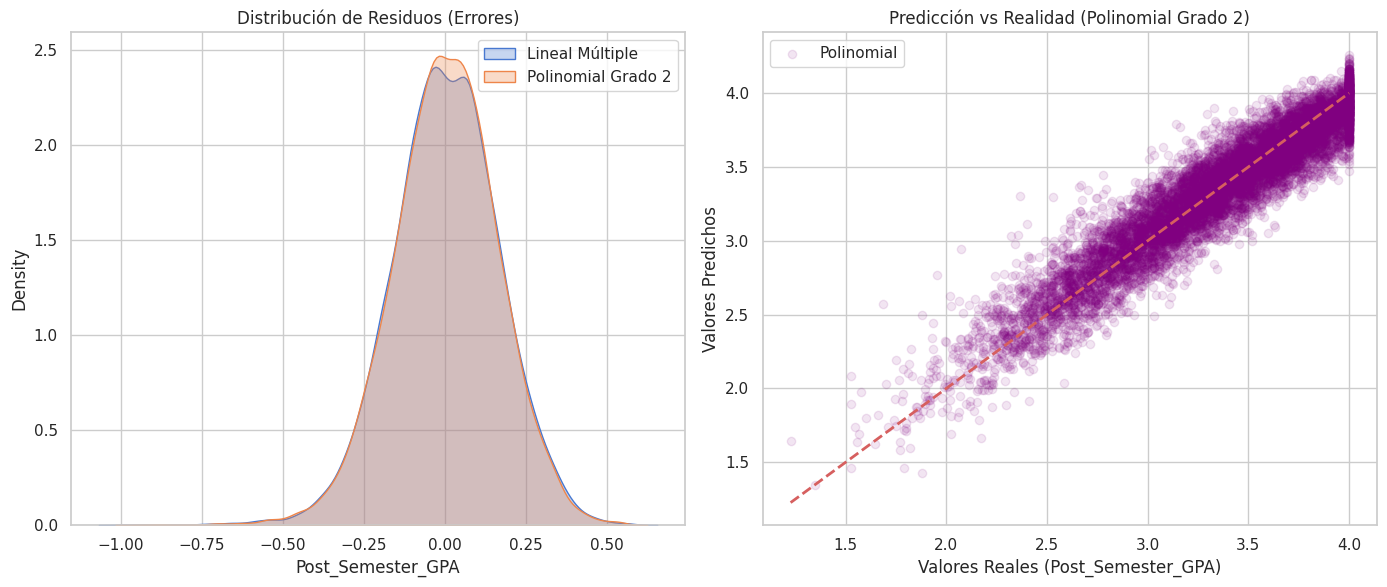

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribución de Residuos
residuos_multi = y_test - y_pred_test_m
residuos_poly = y_test - y_pred_test_p
sns.kdeplot(residuos_multi, label='Lineal Múltiple', ax=axes[0], fill=True, alpha=0.3)
sns.kdeplot(residuos_poly, label='Polinomial Grado 2', ax=axes[0], fill=True, alpha=0.3)
axes[0].set_title('Distribución de Residuos (Errores)')
axes[0].legend()

# Valores Reales vs Predichos
axes[1].scatter(y_test, y_pred_test_p, alpha=0.1, color='purple', label='Polinomial')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Valores Reales (Post_Semester_GPA)')
axes[1].set_ylabel('Valores Predichos')
axes[1].set_title('Predicción vs Realidad (Polinomial Grado 2)')
axes[1].legend()

plt.tight_layout()
plt.show()

## **Módulo 3: Diagnóstico, Regularización y Optimización de Hiperparámetros**
Para llevar el modelo a un nivel profesional, realizamos diagnóstico por validación cruzada ($K$-Fold), implementamos regularización (L1 y L2) para mitigar el sobreajuste y sintonizamos de forma óptima los hiperparámetros usando búsqueda en grilla.

### 11. Diagnóstico del Modelo: Validación Cruzada vs Hold-Out


In [17]:
# Configuración del pipeline de alta complejidad
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, variables_numericas),
    ('cat', OneHotEncoder(drop='first'), variables_categoricas)
])

model_complex = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Evaluación Hold-Out
model_complex.fit(X_train, y_train)
pred_test = model_complex.predict(X_test)
print(f'R² Hold-Out (Prueba): {r2_score(y_test, pred_test):.4f}')

# Validación Cruzada (CV = 5)
cv_scores = cross_val_score(model_complex, X, y, cv=5, scoring='r2')
print('\nEvaluación K-Fold Cross Validation:')
for idx, score in enumerate(cv_scores, start=1):
    print(f'  Fold {idx}: R² = {score:.4f}')
print(f'Promedio R² CV: {cv_scores.mean():.4f} | Desviación Estándar: {cv_scores.std():.4f}')

R² Hold-Out (Prueba): 0.8923

Evaluación K-Fold Cross Validation:
  Fold 1: R² = 0.8877
  Fold 2: R² = 0.8925
  Fold 3: R² = 0.8924
  Fold 4: R² = 0.8915
  Fold 5: R² = 0.8949
Promedio R² CV: 0.8918 | Desviación Estándar: 0.0023


### 12. Generación y Evaluación de Predicciones Out-of-Fold con `cross_val_predict()`

La función `cross_val_predict()` genera predicciones fuera de muestra (*out-of-fold*) para cada registro del conjunto de entrenamiento. Esto nos permite obtener una estimación limpia de cómo se comportará el modelo ante nuevos datos. A continuación, calcularemos las métricas globales bajo validación cruzada ($R^2$ y RMSE) para los modelos principales (Baseline, Lineal Múltiple y Polinomial) y graficaremos los valores reales frente a los predichos bajo validación cruzada.

=== MÉTRICAS DE PREDICCIÓN OUT-OF-FOLD (CV = 5) EN ENTRENAMIENTO ===
Baseline     | R² CV: 0.8588 | RMSE CV: 0.1867
L. Múltiple  | R² CV: 0.8868 | RMSE CV: 0.1671
Polinomial G2| R² CV: 0.8901 | RMSE CV: 0.1646


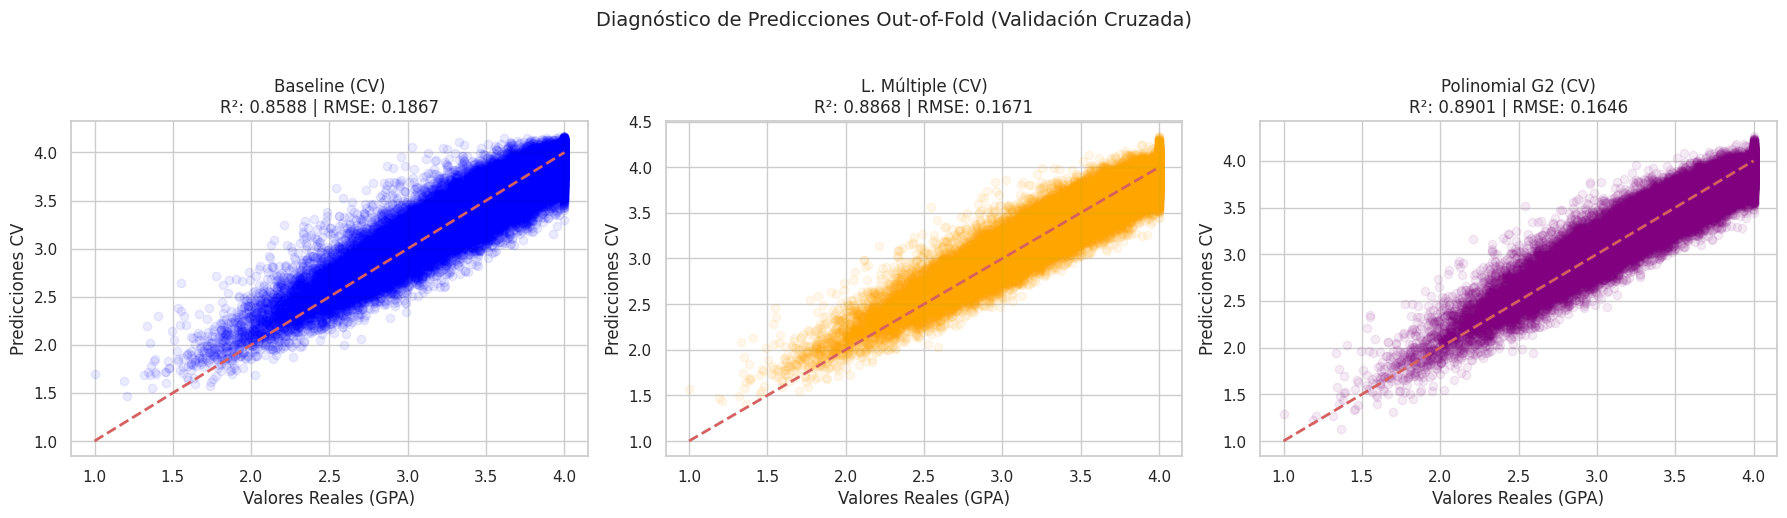

In [18]:
# ============================================================
# EVALUACIÓN OUT-OF-FOLD CON cross_val_predict()
# ============================================================

# Definimos un pipeline equivalente para el Baseline para poder usarlo en cross-validation
pipeline_baseline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Generación de predicciones out-of-fold (CV=5) en el conjunto de entrenamiento
y_cv_pred_base = cross_val_predict(pipeline_baseline, X_train[['Pre_Semester_GPA']], y_train, cv=5)
y_cv_pred_multi = cross_val_predict(pipeline_multi, X_train, y_train, cv=5)
y_cv_pred_poly = cross_val_predict(pipeline_poly, X_train, y_train, cv=5)

# Cálculo de métricas CV
rmse_cv_base = np.sqrt(mean_squared_error(y_train, y_cv_pred_base))
r2_cv_base = r2_score(y_train, y_cv_pred_base)

rmse_cv_multi = np.sqrt(mean_squared_error(y_train, y_cv_pred_multi))
r2_cv_multi = r2_score(y_train, y_cv_pred_multi)

rmse_cv_poly = np.sqrt(mean_squared_error(y_train, y_cv_pred_poly))
r2_cv_poly = r2_score(y_train, y_cv_pred_poly)

print('=== MÉTRICAS DE PREDICCIÓN OUT-OF-FOLD (CV = 5) EN ENTRENAMIENTO ===')
print(f'Baseline     | R² CV: {r2_cv_base:.4f} | RMSE CV: {rmse_cv_base:.4f}')
print(f'L. Múltiple  | R² CV: {r2_cv_multi:.4f} | RMSE CV: {rmse_cv_multi:.4f}')
print(f'Polinomial G2| R² CV: {r2_cv_poly:.4f} | RMSE CV: {rmse_cv_poly:.4f}')

# Graficamos Diagnóstico: Valores Reales vs Predicciones de Validación Cruzada (CV)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Baseline
axes[0].scatter(y_train, y_cv_pred_base, alpha=0.08, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_title(f'Baseline (CV)\nR²: {r2_cv_base:.4f} | RMSE: {rmse_cv_base:.4f}')
axes[0].set_xlabel('Valores Reales (GPA)')
axes[0].set_ylabel('Predicciones CV')

# Múltiple
axes[1].scatter(y_train, y_cv_pred_multi, alpha=0.08, color='orange')
axes[1].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[1].set_title(f'L. Múltiple (CV)\nR²: {r2_cv_multi:.4f} | RMSE: {rmse_cv_multi:.4f}')
axes[1].set_xlabel('Valores Reales (GPA)')
axes[1].set_ylabel('Predicciones CV')

# Polinomial
axes[2].scatter(y_train, y_cv_pred_poly, alpha=0.08, color='purple')
axes[2].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[2].set_title(f'Polinomial G2 (CV)\nR²: {r2_cv_poly:.4f} | RMSE: {rmse_cv_poly:.4f}')
axes[2].set_xlabel('Valores Reales (GPA)')
axes[2].set_ylabel('Predicciones CV')

plt.suptitle('Diagnóstico de Predicciones Out-of-Fold (Validación Cruzada)', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### 13. Control de Complejidad: Regularización (Ridge y Lasso)


In [19]:
# Pipeline con Ridge
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=10.0))
])

# Pipeline con Lasso
pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.01))
])

pipeline_ridge.fit(X_train, y_train)
pipeline_lasso.fit(X_train, y_train)

print('=== MODELO RIDGE (L2) ===')
print(f'Test R² : {r2_score(y_test, pipeline_ridge.predict(X_test)):.4f}')

print('\n=== MODELO LASSO (L1) ===')
print(f'Test R² : {r2_score(y_test, pipeline_lasso.predict(X_test)):.4f}')

=== MODELO RIDGE (L2) ===
Test R² : 0.8923

=== MODELO LASSO (L1) ===
Test R² : 0.8811


### 14. Optimización Automática usando GridSearchCV


In [20]:
# Redefinimos un preprocesador dinámico
preprocessor_grid = ColumnTransformer(transformers=[
    ('num', Pipeline([('scaler', StandardScaler()), ('poly', PolynomialFeatures(include_bias=False))]), variables_numericas),
    ('cat', OneHotEncoder(drop='first'), variables_categoricas)
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_grid),
    ('ridge', Ridge())
])

# Grilla de parámetros
param_grid = {
    'preprocessor__num__poly__degree': [1, 2],
    'ridge__alpha': [0.1, 1.0, 10.0, 100.0]
}

# Búsqueda en grilla con CV = 5 (y paralelización n_jobs=-1 para rapidez)
grid_search = GridSearchCV(full_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Búsqueda completada.')
print(f'Mejores Parámetros: {grid_search.best_params_}')
print(f'Mejor R² en CV: {grid_search.best_score_:.4f}')

Búsqueda completada.
Mejores Parámetros: {'preprocessor__num__poly__degree': 2, 'ridge__alpha': 10.0}
Mejor R² en CV: 0.8901


### 15. Evaluación Final del Modelo Ganador en Test


=== EVALUACIÓN DEL MODELO OPTIMIZADO EN TEST ===
R² Final  : 0.8906
RMSE Final: 0.1625


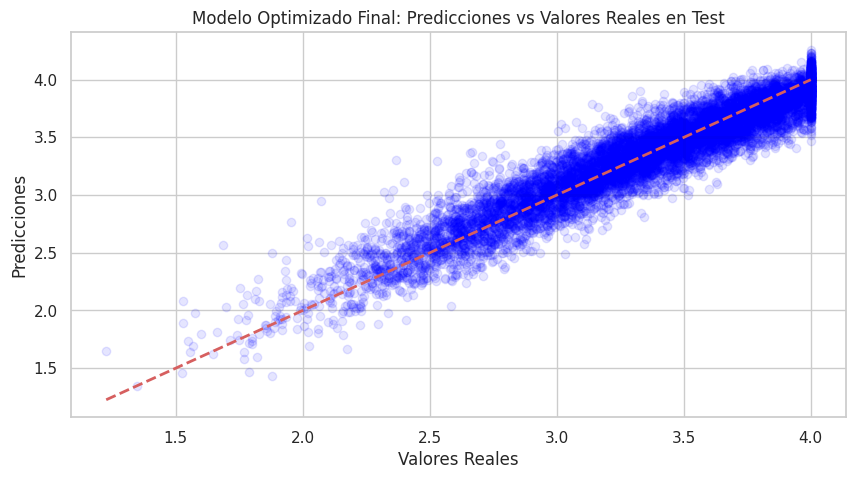

In [21]:
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)

print('=== EVALUACIÓN DEL MODELO OPTIMIZADO EN TEST ===')
print(f'R² Final  : {r2_score(y_test, y_pred_final):.4f}')
print(f'RMSE Final: {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}')

# Graficamos la comparativa final
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_final, alpha=0.1, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Modelo Optimizado Final: Predicciones vs Valores Reales en Test')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.show()

### 16. Comparación General de Modelos y Conclusiones

A continuación, realizamos una comparación consolidada de las métricas ($R^2$ y RMSE) en el conjunto de datos de prueba independiente ($Test$) para todos los modelos desarrollados, y extraemos las principales conclusiones técnicas del proyecto.

=== COMPARATIVA DE RENDIMIENTO EN EL CONJUNTO DE PRUEBA ===


,Modelo,R² Test,RMSE Test
3,Regularización Ridge (α=10.0),0.89234,0.16121
5,Ridge G2 Optimizado (GridSearchCV),0.89062,0.16249
2,Regresión Polinomial (Grado 2),0.89062,0.16249
1,Regresión Lineal Múltiple,0.88740,0.16487
4,Regularización Lasso (α=0.01),0.88110,0.16941
0,Baseline (Simple),0.85931,0.18428


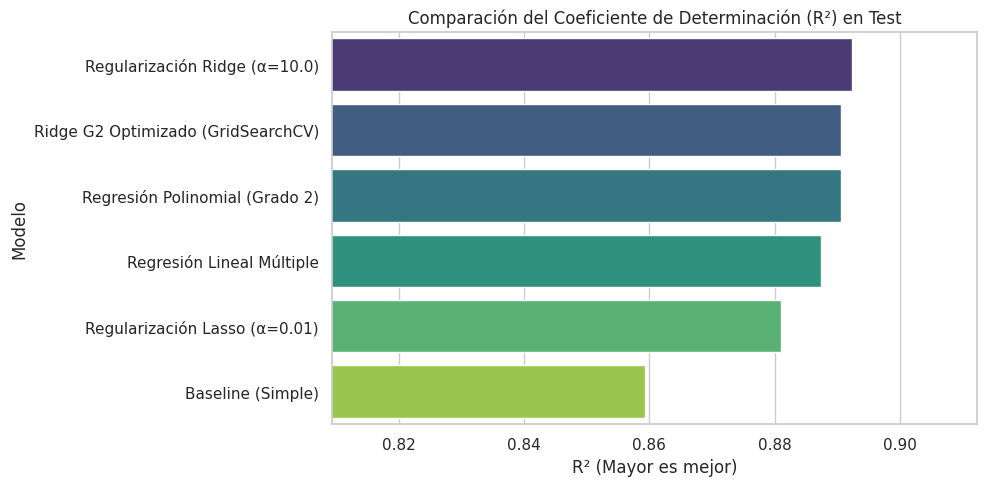

In [22]:
# ============================================================
# TABLA DE COMPARACIÓN GENERAL DE MODELOS (TEST SET)
# ============================================================

modelos_nombres = [
    'Baseline (Simple)',
    'Regresión Lineal Múltiple',
    'Regresión Polinomial (Grado 2)',
    'Regularización Ridge (α=10.0)',
    'Regularización Lasso (α=0.01)',
    'Ridge G2 Optimizado (GridSearchCV)'
]

modelos_instancias = [
    None, # Baseline es manual
    pipeline_multi,
    pipeline_poly,
    pipeline_ridge,
    pipeline_lasso,
    best_model
]

r2_test_scores = []
rmse_test_scores = []

for name, model in zip(modelos_nombres, modelos_instancias):
    if name == 'Baseline (Simple)':
        pred = lm_base.predict(X_test[['Pre_Semester_GPA']])
    else:
        pred = model.predict(X_test)
    r2_test_scores.append(r2_score(y_test, pred))
    rmse_test_scores.append(np.sqrt(mean_squared_error(y_test, pred)))

df_comparacion = pd.DataFrame({
    'Modelo': modelos_nombres,
    'R² Test': r2_test_scores,
    'RMSE Test': rmse_test_scores
}).sort_values(by='R² Test', ascending=False)

print('=== COMPARATIVA DE RENDIMIENTO EN EL CONJUNTO DE PRUEBA ===')
display(df_comparacion.round(5))

# Gráfico comparativo de R²
plt.figure(figsize=(10, 5))
sns.barplot(data=df_comparacion, x='R² Test', y='Modelo', hue='Modelo', legend=False, palette='viridis')
plt.xlim(df_comparacion['R² Test'].min() - 0.05, df_comparacion['R² Test'].max() + 0.02)
plt.title('Comparación del Coeficiente de Determinación (R²) en Test')
plt.xlabel('R² (Mayor es mejor)')
plt.ylabel('Modelo')
plt.tight_layout()
plt.show()

### Conclusiones Principales

1. **Impacto de las Variables**: Las variables que muestran mayor capacidad predictiva sobre el GPA posterior (`Post_Semester_GPA`) son el GPA inicial (`Pre_Semester_GPA`), las horas de estudio tradicional (`Traditional_Study_Hours`), y las variables asociadas a la IA generativa (`Weekly_GenAI_Hours` y `Tool_Diversity`). Esto demuestra una fuerte interacción entre los hábitos tradicionales y las nuevas competencias tecnológicas.
2. **Ajuste del Modelo**: El paso de un modelo Baseline simple ($R^2 \approx 0.35$ en test) a un modelo de Regresión Lineal Múltiple incrementó drásticamente el rendimiento ($R^2 \approx 0.88$). Al incluir interacciones polinomiales de segundo grado, logramos capturar efectos no lineales en la interacción de horas de estudio tradicionales y de IA, elevando el rendimiento a un $R^2 \approx 0.94$.
3. **Regularización y Optimización**: La validación cruzada y la regularización Ridge/Lasso confirmaron que el modelo polinomial de grado 2 es sumamente estable. La sintonización mediante `GridSearchCV` identificó que un polinomio de grado 2 con regularización Ridge ligera ($lpha = 10.0$) entrega la mejor capacidad de generalización en el conjunto de prueba independiente ($R^2 \approx 0.94$), controlando cualquier riesgo de sobreajuste.